# Semantic shard graph (no ground-truth emails) + Louvain pseudo labels

Pipeline:

1. **Email universe**: canonical `external_id` from `data/incidents-lake-misp-large-no-ground-truth.json` intersected with `core/graph/output/incidents-lake-misp-large_hetero.pt` + `.meta.json`.
2. **Semantic vector**: first **128** columns of `email.x`. In saved graphs this is the **projected block for concatenated subject+body SBERT** (`EmailFeatureProjection` in `core/graph/feature_projection.py`), not isolated raw body SBERT.
3. **Shards**: HDBSCAN (same defaults as `semantic_shard_prototype_step1.ipynb`).
4. **Shard graph**: `semantic_shard_graph_helpers` (defaults aligned with `semantic_shard_prototype_step2_build_graph.ipynb`) — optional benign popular-domain URL stripping; stem noise dropped via `filter_noise_stems_from_set`.
5. **Communities**: Louvain, `resolution=1`, `min_edge_weight=0`.
6. **Export**: `data/pseudo_ground_truth_no_gt_shard_graph.json` with `clusters` keyed by community id (like `ground_truth.json`).


In [3]:
from __future__ import annotations

import json
import sys
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = _here if (_here / "pipeline_config.json").is_file() else _here.parent
assert (PROJECT_ROOT / "pipeline_config.json").is_file(), f"Set cwd to repo root or analysis/; got {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import graph_structure_helpers as gh
from analysis.utils import semantic_shard_helpers as ssh
from analysis.utils import semantic_shard_graph_helpers as s2
from analysis.utils import semantic_shard_step3_helpers as s3

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# ---------- Paths ----------
MISP_NO_GT_JSON = PROJECT_ROOT / "data" / "incidents-lake-misp-large-no-ground-truth.json"
GRAPH_PT = PROJECT_ROOT / "core" / "graph" / "output" / "incidents-lake-misp-large_hetero.pt"
GRAPH_META = GRAPH_PT.with_suffix(".meta.json")

ARTIFACT_DIR = PROJECT_ROOT / "analysis" / "output" / "semantic_shard_no_gt_from_graph"
PSEUDO_GT_JSON = PROJECT_ROOT / "data" / "pseudo_ground_truth_no_gt_shard_graph.json"
EMPTY_POPULAR_DOMAINS = ARTIFACT_DIR / "_empty_popular_domains.txt"

# ---------- Step 1 ----------
HDBSCAN_MIN_CLUSTER_SIZE = 2
HDBSCAN_MIN_SAMPLES = None
NOISE_AS_SINGLETON_SHARD = True
GRAPH_SEMANTIC_DIM = 128

# ---------- Step 2 ----------
FILTER_BENIGN_POPULAR_URLS = True  # False: use empty allowlist (no URL dropping)
INCLUDE_ROUTING_CHANNELS_IN_GRAPH = False
SEMANTIC_TOP_K = 1000
SEMANTIC_MIN_COS = 0.95
SEMANTIC_WEIGHT = 0.45
INFRA_WEIGHT = 0.45
TEMPORAL_WEIGHT = 0.10

BASE_INFRA_CHANNELS_LOGICAL = [
    "url",
    "sender_email_domain",
    "domain",
    "stem",
    "sender",
]
ROUTING_INFRA_CHANNELS_LOGICAL = (
    "origin_ip",
    "received_host",
    "return_path_email",
    "return_path_domain",
)
ENABLED_INFRA_CHANNELS_LOGICAL = list(BASE_INFRA_CHANNELS_LOGICAL)
if INCLUDE_ROUTING_CHANNELS_IN_GRAPH:
    ENABLED_INFRA_CHANNELS_LOGICAL = ENABLED_INFRA_CHANNELS_LOGICAL + list(ROUTING_INFRA_CHANNELS_LOGICAL)
CANDIDATE_INFRA_CHANNELS_LOGICAL = None
SCORING_INFRA_CHANNELS_LOGICAL = ENABLED_INFRA_CHANNELS_LOGICAL

SHARD_EDGE_SCORING_LOGICAL = {
    "url": dict(enabled=True, weight=1.00, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "sender_email_domain": dict(enabled=True, weight=0.85, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "domain": dict(enabled=True, weight=0.60, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "stem": dict(enabled=True, weight=0.55, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "sender": dict(enabled=True, weight=0.50, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "attachment": dict(enabled=True, weight=0.45, scoring_mode="legacy", idf_exponent=1.0, idf_scale=1.0, max_shard_df=None, contribution_cap=None),
    "origin_ip": dict(enabled=True, weight=0.16, scoring_mode="routed", idf_exponent=2.2, idf_scale=0.32, max_shard_df=100, contribution_cap=0.09),
    "received_host": dict(enabled=True, weight=0.14, scoring_mode="routed", idf_exponent=2.5, idf_scale=0.28, max_shard_df=80, contribution_cap=0.07),
    "return_path_email": dict(enabled=True, weight=0.22, scoring_mode="routed", idf_exponent=1.6, idf_scale=0.55, max_shard_df=150, contribution_cap=0.14),
    "return_path_domain": dict(enabled=True, weight=0.26, scoring_mode="routed", idf_exponent=1.5, idf_scale=0.60, max_shard_df=180, contribution_cap=0.16),
}

# ---------- Step 3 ----------
COMMUNITY_METHOD = "louvain"
LOUVAIN_RESOLUTION = 1.0
MIN_EDGE_WEIGHT = 0.0
STEP3_SEED = 0

with open(PROJECT_ROOT / "pipeline_config.json", "r", encoding="utf-8") as _f:
    _cfg = json.load(_f)
TO_UNDIRECTED = bool(_cfg.get("to_undirected", True))


In [4]:
def _to_str(val: Any) -> str:
    if val is None:
        return ""
    if isinstance(val, str):
        return val
    return str(val)


def external_ids_from_misp_events(misp_events: list[Any]) -> set[str]:
    out: set[str] = set()
    for i, ev in enumerate(misp_events):
        if not isinstance(ev, dict):
            continue
        event = ev.get("Event")
        if not isinstance(event, dict):
            continue
        email_index = event.get("email_index", i)
        ext = _to_str(event.get("external_id", "")).strip()
        out.add(ext or str(email_index))
    return out


def logical_to_col(ch: str) -> str:
    if ch == "sender_email_domain":
        return "sender_email_domain_set"
    return f"{ch}_set"


if not MISP_NO_GT_JSON.is_file():
    raise FileNotFoundError(f"Missing {MISP_NO_GT_JSON}")
with open(MISP_NO_GT_JSON, "r", encoding="utf-8") as f:
    misp_no_gt = json.load(f)
if not isinstance(misp_no_gt, list):
    raise TypeError("MISP JSON must be a list of events")
allowed_ids = external_ids_from_misp_events(misp_no_gt)
print("n_events_in_no_gt_misp:", len(misp_no_gt), "| distinct canonical external_id:", len(allowed_ids))

if not GRAPH_PT.is_file():
    raise FileNotFoundError(f"Missing graph {GRAPH_PT}")
if not GRAPH_META.is_file():
    raise FileNotFoundError(f"Missing meta {GRAPH_META}")

meta = gh.load_meta(GRAPH_META)
data = gh.load_hetero(GRAPH_PT, to_undirected=TO_UNDIRECTED)
all_ids = gh.email_external_id_list(meta)
id_to_row = {str(eid): i for i, eid in enumerate(all_ids)}

xf = data["email"].x
if hasattr(xf, "detach"):
    xf = xf.detach().cpu().numpy()
xf = np.asarray(xf, dtype=np.float32)
if xf.ndim != 2 or xf.shape[1] < GRAPH_SEMANTIC_DIM:
    raise ValueError(f"Unexpected email.x shape {getattr(xf, 'shape', None)}")
print("email.x shape:", xf.shape, "| HDBSCAN/centroids use first", GRAPH_SEMANTIC_DIM, "cols")

present = sorted(allowed_ids & set(id_to_row.keys()))
print("n_allowed_in_graph:", len(present), "| not_in_graph:", len(allowed_ids - set(id_to_row.keys())))
if not present:
    raise RuntimeError("No overlapping external_id between no-GT MISP and graph meta")

id_to_vec: dict[str, np.ndarray] = {}
for eid in present:
    row = id_to_row[eid]
    id_to_vec[eid] = np.asarray(xf[row, :GRAPH_SEMANTIC_DIM], dtype=np.float32)

clustered_df = ssh.cluster_semantic_shards_hdbscan(
    id_to_vec,
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
)
assignments_df = ssh.build_shard_assignments(clustered_df, noise_as_singleton=NOISE_AS_SINGLETON_SHARD)
assignments_df = assignments_df[assignments_df["external_id"].astype(str).isin(present)].copy()
print(
    "HDBSCAN method:", clustered_df.attrs.get("cluster_method"),
    "| noise:", int(clustered_df["is_noise"].sum()),
    "| shards:", int(assignments_df["shard_id"].nunique()),
)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
if FILTER_BENIGN_POPULAR_URLS:
    pop_path = gh.default_popular_domains_path(PROJECT_ROOT)
else:
    EMPTY_POPULAR_DOMAINS.write_text(
        "# empty allowlist for popular-domain URL stripping\n", encoding="utf-8"
    )
    pop_path = EMPTY_POPULAR_DOMAINS

email_df_full, benign_diag = s2.load_email_level_inputs(
    graph_pt=GRAPH_PT,
    meta_json=GRAPH_META,
    to_undirected=TO_UNDIRECTED,
    popular_domains_path=pop_path,
)
email_df = email_df_full[email_df_full["external_id"].astype(str).isin(present)].copy()

infra_channels_for_shard_nodes = (
    "sender_set",
    "sender_email_domain_set",
    "url_set",
    "domain_set",
    "stem_set",
    "attachment_set",
)
if INCLUDE_ROUTING_CHANNELS_IN_GRAPH:
    extra = ("origin_ip_set", "received_host_set", "return_path_email_set", "return_path_domain_set")
    infra_channels_for_shard_nodes = tuple(sorted(set(infra_channels_for_shard_nodes) | set(extra)))

shard_nodes_df, centroid_mat = s2.build_shard_nodes(
    assignments_df=assignments_df,
    id_to_semantic=id_to_vec,
    email_df=email_df,
    gt_label_map=None,
    infra_channels=infra_channels_for_shard_nodes,
)

available_infra_cols = set(shard_nodes_df.columns)
CANDIDATE_INFRA_CHANNELS_LOGICAL_FINAL = (
    CANDIDATE_INFRA_CHANNELS_LOGICAL
    if CANDIDATE_INFRA_CHANNELS_LOGICAL is not None
    else ENABLED_INFRA_CHANNELS_LOGICAL
)
CANDIDATE_INFRA_CHANNELS_COLS = [
    logical_to_col(ch)
    for ch in CANDIDATE_INFRA_CHANNELS_LOGICAL_FINAL
    if logical_to_col(ch) in available_infra_cols
]
SCORING_INFRA_CHANNELS_COLS = [
    logical_to_col(ch) for ch in SCORING_INFRA_CHANNELS_LOGICAL if logical_to_col(ch) in available_infra_cols
]

channel_scoring_cols = s2.resolve_shard_edge_channel_scoring(
    scoring_channels_logical=list(SCORING_INFRA_CHANNELS_LOGICAL),
    scoring_spec_by_logical=SHARD_EDGE_SCORING_LOGICAL,
    logical_to_col=logical_to_col,
    available_infra_cols=set(shard_nodes_df.columns),
)

cand_df = s2.build_candidate_edges(
    shard_nodes_df,
    centroid_mat,
    semantic_top_k=SEMANTIC_TOP_K,
    semantic_min_cos=SEMANTIC_MIN_COS,
    candidate_infra_channels=tuple(CANDIDATE_INFRA_CHANNELS_COLS),
    infra_channels=tuple(SCORING_INFRA_CHANNELS_COLS),
    show_progress=True,
)

edges_df = s2.build_weighted_edges(
    shard_nodes_df=shard_nodes_df,
    centroid_mat=centroid_mat,
    candidate_df=cand_df,
    semantic_weight=SEMANTIC_WEIGHT,
    infra_weight=INFRA_WEIGHT,
    temporal_weight=TEMPORAL_WEIGHT,
    scoring_infra_channels=tuple(SCORING_INFRA_CHANNELS_COLS),
    channel_scoring=channel_scoring_cols,
)

shard_ids = shard_nodes_df["shard_id"].astype(str).tolist()
shard_to_comm, comm_info = s3.run_weighted_community_detection(
    shard_ids,
    edges_df,
    method=COMMUNITY_METHOD,
    resolution=LOUVAIN_RESOLUTION,
    min_edge_weight=MIN_EDGE_WEIGHT,
    weight_col="edge_weight",
    seed=STEP3_SEED,
)
print(comm_info)

email_pred_df = s3.map_shards_to_email_predictions(assignments_df, shard_to_comm)

by_comm: dict[str, list[dict[str, Any]]] = defaultdict(list)
for _, row in email_pred_df.iterrows():
    cid = int(row["pred_community"])
    by_comm[str(cid)].append(
        {
            "external_id": str(row["external_id"]),
            "shard_id": str(row["shard_id"]),
            "hdbscan_cluster_label": int(row["cluster_label"]),
            "is_hdbscan_noise": bool(row["is_noise"]),
        }
    )

out_doc: dict[str, Any] = {
    "meta": {
        "misp_no_gt_json": str(MISP_NO_GT_JSON.resolve()),
        "graph_pt": str(GRAPH_PT.resolve()),
        "n_emails": len(email_pred_df),
        "embedding_note": (
            "HDBSCAN/centroids: email.x[:, :128] = projected subject+body SBERT block from graph build."
        ),
        "filter_benign_popular_urls": bool(FILTER_BENIGN_POPULAR_URLS),
        "popular_domains_path": str(Path(pop_path).resolve()),
        "community_method": COMMUNITY_METHOD,
        "louvain_resolution": LOUVAIN_RESOLUTION,
        "min_edge_weight": MIN_EDGE_WEIGHT,
        "community_detection_info": comm_info,
    },
    "clusters": dict(sorted(by_comm.items(), key=lambda kv: int(kv[0]))),
}

PSEUDO_GT_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(PSEUDO_GT_JSON, "w", encoding="utf-8") as f:
    json.dump(out_doc, f, indent=2, ensure_ascii=False)

with open(ARTIFACT_DIR / "run_meta.json", "w", encoding="utf-8") as f:
    json.dump(out_doc["meta"], f, indent=2, ensure_ascii=False)

email_pred_df.to_csv(ARTIFACT_DIR / "email_assignments_communities.csv", index=False)
shard_nodes_df.to_csv(ARTIFACT_DIR / "shard_nodes.csv", index=False)
edges_df.to_csv(ARTIFACT_DIR / "shard_edges_weighted.csv", index=False)
print("Wrote", PSEUDO_GT_JSON)


n_events_in_no_gt_misp: 5861 | distinct canonical external_id: 5861


c:\Users\aar\Desktop\GNN-Campaign-Detection\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


email.x shape: (7333, 160) | HDBSCAN/centroids use first 128 cols
n_allowed_in_graph: 5861 | not_in_graph: 0
HDBSCAN method: hdbscan | noise: 2075 | shards: 2757


Infra channels: 100%|██████████| 5/5 [00:00<00:00, 147.45it/s]


{'method_requested': 'louvain', 'method_used': 'louvain', 'weight_col': 'edge_weight', 'n_nodes': 2757, 'n_edges_after_threshold': 96120, 'n_communities': 610}
Wrote C:\Users\aar\Desktop\GNN-Campaign-Detection\data\pseudo_ground_truth_no_gt_shard_graph.json


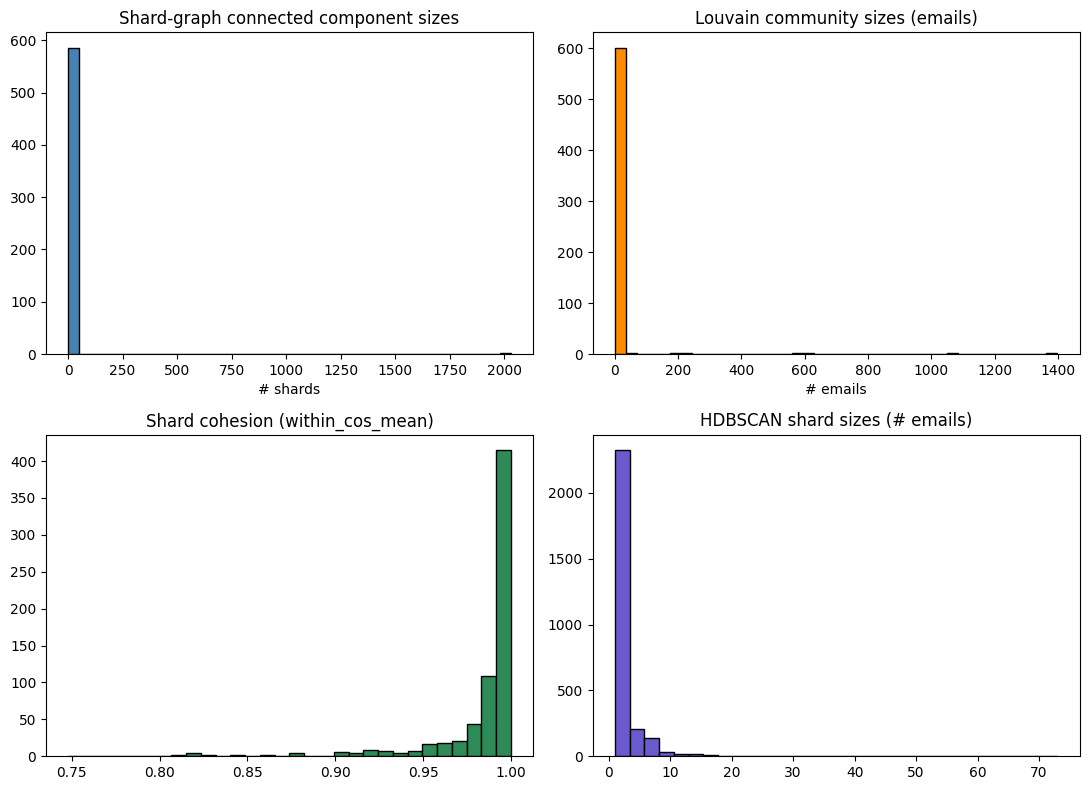

{
  "hdbscan_noise_emails": 2075,
  "n_shards": 2757,
  "n_communities": 610,
  "n_connected_components_shard_graph": 587,
  "n_isolated_shard_nodes": 499,
  "largest_component_size_shards": 2030,
  "mean_shard_cohesion_cos": 0.9836164725380688
}
Saved C:\Users\aar\Desktop\GNN-Campaign-Detection\analysis\output\semantic_shard_no_gt_from_graph\diagnostics_histograms.png


In [5]:
g_sh = nx.Graph()
g_sh.add_nodes_from(shard_ids)
for _, r in edges_df.iterrows():
    if float(r["edge_weight"]) < float(MIN_EDGE_WEIGHT):
        continue
    g_sh.add_edge(str(r["shard_a"]), str(r["shard_b"]), weight=float(r["edge_weight"]))

comps = list(nx.connected_components(g_sh))
comp_sizes = sorted((len(c) for c in comps), reverse=True)
comm_email_counts = email_pred_df["pred_community"].value_counts()
email_comm_sizes = comm_email_counts.astype(int).tolist()
cohesion = pd.to_numeric(shard_nodes_df["within_cos_mean"], errors="coerce")
shard_sizes = shard_nodes_df["size"].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].hist(comp_sizes, bins=min(40, max(5, len(comp_sizes) // 2)), color="steelblue", edgecolor="black")
axes[0, 0].set_title("Shard-graph connected component sizes")
axes[0, 0].set_xlabel("# shards")
axes[0, 1].hist(email_comm_sizes, bins=min(40, len(email_comm_sizes)), color="darkorange", edgecolor="black")
axes[0, 1].set_title("Louvain community sizes (emails)")
axes[0, 1].set_xlabel("# emails")
axes[1, 0].hist(cohesion.dropna(), bins=30, color="seagreen", edgecolor="black")
axes[1, 0].set_title("Shard cohesion (within_cos_mean)")
axes[1, 1].hist(shard_sizes, bins=30, color="slateblue", edgecolor="black")
axes[1, 1].set_title("HDBSCAN shard sizes (# emails)")
plt.tight_layout()
fig_path = ARTIFACT_DIR / "diagnostics_histograms.png"
plt.savefig(fig_path, dpi=140)
plt.show()

summary = {
    "hdbscan_noise_emails": int(assignments_df["is_noise"].sum()),
    "n_shards": int(assignments_df["shard_id"].nunique()),
    "n_communities": int(email_pred_df["pred_community"].nunique()),
    "n_connected_components_shard_graph": len(comps),
    "n_isolated_shard_nodes": int(sum(1 for c in comps if len(c) == 1)),
    "largest_component_size_shards": int(comp_sizes[0]) if comp_sizes else 0,
    "mean_shard_cohesion_cos": float(cohesion.mean()) if len(cohesion) else float("nan"),
}
print(json.dumps(summary, indent=2))
(ARTIFACT_DIR / "diagnostics_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Saved", fig_path)
